<a href="https://colab.research.google.com/github/remyaP12/labcycle_3sem/blob/main/99labcycle2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.3174 - val_loss: 0.1434
Epoch 2/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1344 - val_loss: 0.1154
Epoch 3/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1129 - val_loss: 0.1063
Epoch 4/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1034 - val_loss: 0.1000
Epoch 5/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0983 - val_loss: 0.0962
Epoch 6/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0944 - val_loss: 0.0931
Epoch 7/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0919 - val_loss: 0.0910
Epoch 8/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0896 - val_loss: 0.0893
Epoch 9/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0877 - val_loss: 0.0879
Epoch 10/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0862 - val_loss: 0.0865
Epoch 11/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0850 - val_loss: 0.0851


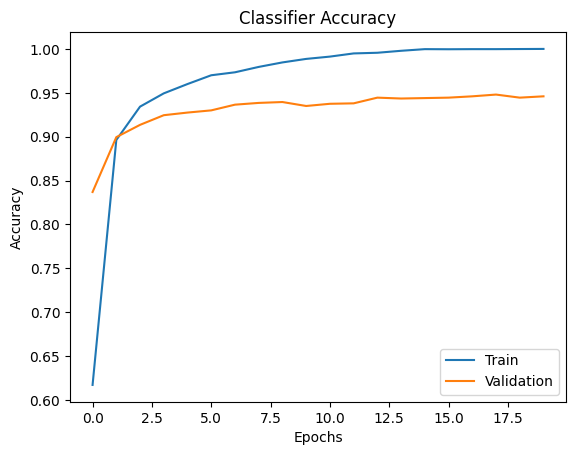

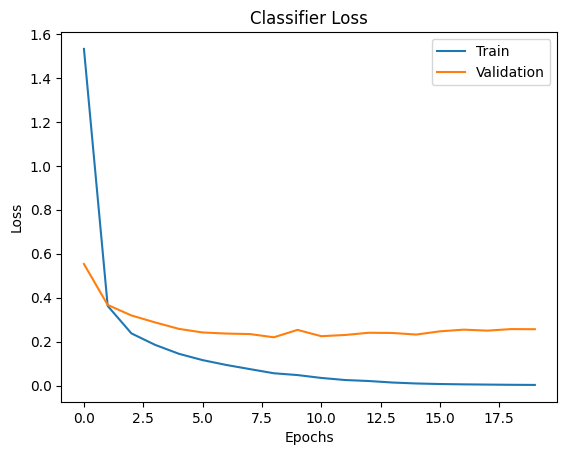

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

y_test_cat = to_categorical(y_test, 10)

labeled_samples = 10000   # only part of data is labeled

X_labeled = X_train[:labeled_samples]
y_labeled = y_train[:labeled_samples]

X_unlabeled = X_train     # full data used for autoencoder

y_labeled_cat = to_categorical(y_labeled, 10)

input_img = Input(shape=(784,))

# Encoder (STACKED)
encoded = Dense(256, activation='relu')(input_img)
encoded = Dense(128, activation='relu')(encoded)
encoded = Dense(64, activation='relu')(encoded)

# Decoder
decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(256, activation='relu')(decoded)
decoded = Dense(784, activation='sigmoid')(decoded)

autoencoder = Model(input_img, decoded)
encoder = Model(input_img, encoded)

autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

history_ae = autoencoder.fit(
    X_unlabeled, X_unlabeled,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    shuffle=True
)

classifier = Sequential([
    encoder,
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

classifier.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_cls = classifier.fit(
    X_labeled, y_labeled_cat,
    epochs=20,
    batch_size=128,
    validation_split=0.2
)

test_loss, test_acc = classifier.evaluate(X_test, y_test_cat)
print("Test Accuracy (Semi-Supervised):", test_acc)

plt.figure()
plt.plot(history_cls.history['accuracy'])
plt.plot(history_cls.history['val_accuracy'])
plt.title("Classifier Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

plt.figure()
plt.plot(history_cls.history['loss'])
plt.plot(history_cls.history['val_loss'])
plt.title("Classifier Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()